In [1]:
# 1. YOLO kütüphanesini kur
!pip install ultralytics

# 2. Kütüphaneyi içeri aktar
from ultralytics import YOLO

# 3. Hızlı eğitim için Nano modeli seç
model = YOLO('yolov8n.pt')

# 4. Eğitimi başlat (25 döngü)
results = model.train(data='/kaggle/input/datasets/andresmgs/plantdec/data.yaml', epochs=30, imgsz=640)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 66.5 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you 

Test resimleri bulundu, hastalıklar tespit ediliyor...

image 1/1 /kaggle/input/datasets/andresmgs/plantdec/test/images/sept4disease_019_jpg.rf.7d5a1ac7d63b933fb38cb6ab2aa22f38.jpg: 640x640 1 Tomato Septoria leaf spot, 7.3ms
Speed: 2.7ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict-2

image 1/1 /kaggle/input/datasets/andresmgs/plantdec/test/images/6447731_orig_jpg.rf.85458f4dd3c3ee26dadfe6a18165276b.jpg: 640x640 1 Tomato Septoria leaf spot, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict-2

image 1/1 /kaggle/input/datasets/andresmgs/plantdec/test/images/resistance1c_jpg.rf.85853725c01aaa852946f52407fcc2cb.jpg: 640x640 1 Blueberry leaf, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict-2


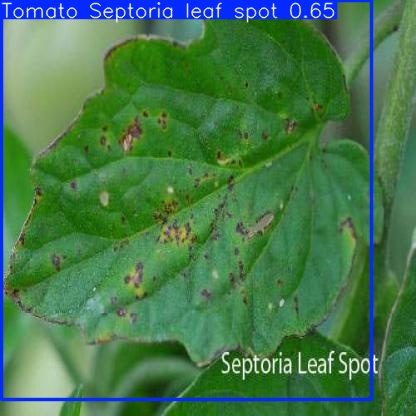

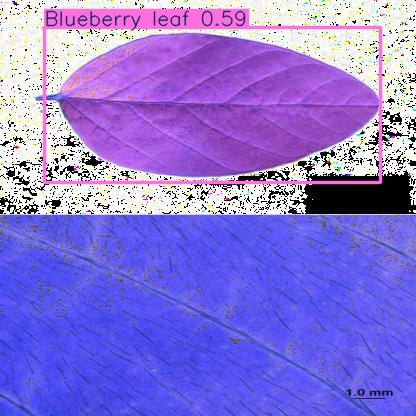

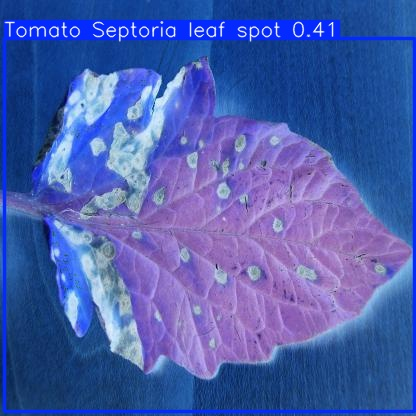

In [3]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

# 1. Az önce eğittiğimiz en iyi modelimizi çağırıyoruz
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# 2. Sistemdeki hazır test resimlerini otomatik bulup 3 tanesini seçiyoruz
test_resimleri = glob.glob('/kaggle/input/**/test/images/*.jpg', recursive=True)[:3]
print("Test resimleri bulundu, hastalıklar tespit ediliyor...")

# 3. Model bu resimlerdeki hastalıkları bulup tahmin ediyor
for resim in test_resimleri:
    model.predict(source=resim, save=True)

# 4. Çizilen sonuç fotoğraflarını ekrana yazdırıyoruz
sonuc_resimleri = glob.glob('/kaggle/working/runs/detect/predict/*.jpg')
for s_resim in sonuc_resimleri:
    display(Image(filename=s_resim))